# **Milestone 4: Refinement**
# **Trajectory Types of Childcare Cost Growth 2008-2018**



A1 Team 6: Yuanhao Li

### Motivation and Executive Summary

Childcare affordability can change slowly over time, so a single year snapshot may hide meaningful patterns. I focus on whether counties follow a small number of recurring childcare cost growth shapes from 2008 to 2018.

In earlier work, clustering raw time series did not separate counties clearly. In this milestone, I summarize each county trajectory into a few interpretable features and then cluster those features. This aims to produce trajectory types that are easier to justify and more robust to noise and missing years.

## 1.Data importing & Preprocessing

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

In [56]:
import numpy as np
import pandas as pd

CHILDCARE_FILE = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/childcare_costs.csv"
COUNTY_REF_FILE = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/counties.csv"

START_YEAR, END_YEAR = 2008, 2018
MIN_YEARS_REQUIRED = 8
MAX_INTERP_GAP = 1

child = pd.read_csv(CHILDCARE_FILE)
counties = pd.read_csv(COUNTY_REF_FILE)

child["county_fips_code"] = child["county_fips_code"].astype(str).str.zfill(5)
counties["county_fips_code"] = counties["county_fips_code"].astype(str).str.zfill(5)

print(child.shape)
print("mc_infant missing rate", round(child["mc_infant"].isna().mean(), 3))

(34567, 61)
mc_infant missing rate 0.317


I reshape mc_infant into a county by year panel and fill small internal gaps so the shapes are not driven by heavy interpolation.

In [57]:
df = child.loc[(child["study_year"].between(START_YEAR, END_YEAR)),
               ["county_fips_code", "study_year", "mc_infant"]].copy()

panel = df.pivot_table(index="county_fips_code", columns="study_year", values="mc_infant", aggfunc="median")

coverage_before = panel.notna().sum(axis=1)
panel = panel.interpolate(axis=1, limit=MAX_INTERP_GAP, limit_area="inside")
coverage_after = panel.notna().sum(axis=1)
panel = panel.loc[coverage_after[coverage_after >= MIN_YEARS_REQUIRED].index].sort_index()

print("counties total", coverage_before.shape[0])
print("counties kept", panel.shape[0])

counties total 2904
counties kept 1987


## 2.Feature engineering


Instead of clustering raw yearly vectors, I summarize each county trajectory using a few interpretable features. I standardize within county so the clustering focuses on shape rather than level.

In [58]:
Z = panel.sub(panel.mean(axis=1), axis=0).div(panel.std(axis=1).replace(0, np.nan), axis=0)
years = Z.columns.values.astype(float)

def make_features(row):
  y = row.values.astype(float)
  m = ~np.isnan(y)
  if m.sum() < 3:
    return pd.Series({"n_years": m.sum(), "slope": np.nan, "volatility": np.nan, "max_abs_change": np.nan})
  x = years[m]
  yv = y[m]
  slope = np.polyfit(x, yv, 1)[0]
  vol = np.std(yv)
  mx = np.max(np.abs(np.diff(yv))) if m.sum() > 1 else 0.0
  return pd.Series({"n_years": m.sum(), "slope": slope, "volatility": vol, "max_abs_change": mx})

feat = Z.apply(make_features, axis=1)
feat = feat.reset_index().merge(
  counties[["county_fips_code", "county_name", "state_name", "state_abbreviation"]].drop_duplicates(),
  on="county_fips_code",
  how="left"
).set_index("county_fips_code")

feat.head()

,n_years,slope,volatility,max_abs_change,county_name,state_name,state_abbreviation
county_fips_code,,,,,,,
01001,11.0,0.260380,0.953463,0.663447,Autauga County,Alabama,AL
01003,11.0,0.197133,0.953463,0.801740,Baldwin County,Alabama,AL
01005,11.0,0.233291,0.953463,0.522437,Barbour County,Alabama,AL
01007,11.0,0.291265,0.953463,0.409049,Bibb County,Alabama,AL
01009,11.0,0.275001,0.953463,0.602262,Blount County,Alabama,AL


## 3.Hierarchical clustering baseline

I use hierarchical clustering on the trajectory features as the main clustering method. This addresses the earlier issue that K means on raw high dimensional trajectories did not clearly separate counties. Hierarchical clustering is a good fit here because it can capture gradual structure and does not rely on spherical cluster assumptions. I choose a reasonable number of clusters using simple diagnostics and then produce baseline cluster labels.


I cluster counties using the engineered features slope volatility and max_abs_change. I standardize these features across counties.

In [59]:
use_cols = ["slope", "volatility", "max_abs_change"]
X = feat[use_cols].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("counties used in clustering", X.shape[0])
X.head()

counties used in clustering 1987


,slope,volatility,max_abs_change
county_fips_code,,,
01001,0.260380,0.953463,0.663447
01003,0.197133,0.953463,0.801740
01005,0.233291,0.953463,0.522437
01007,0.291265,0.953463,0.409049
01009,0.275001,0.953463,0.602262




I plot a dendrogram to get a qualitative sense of how counties merge under hierarchical clustering.

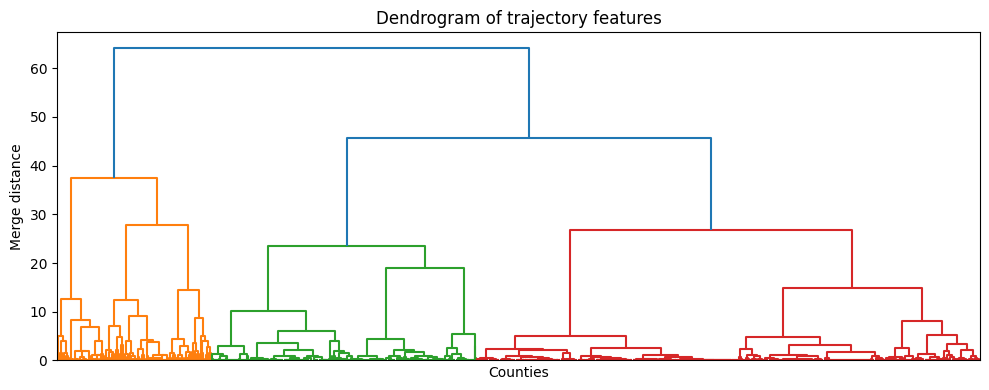

In [60]:
Z_link = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(Z_link, no_labels=True, color_threshold=None)
plt.title("Dendrogram of trajectory features")
plt.xlabel("Counties")
plt.ylabel("Merge distance")
plt.tight_layout()
plt.show()

I compute silhouette scores on a small range of K as a rough separation diagnostic. I check cluster sizes so I avoid solutions that create tiny clusters that are hard to interpret.

In [34]:
k_list = list(range(2, 9))

rows = []
for k in k_list:
  model = AgglomerativeClustering(n_clusters=k, linkage="ward")
  labels = model.fit_predict(X_scaled)

  sil = silhouette_score(X_scaled, labels)
  sizes = pd.Series(labels).value_counts().sort_index()
  min_size = int(sizes.min())

  rows.append({"k": k, "silhouette": sil, "min_cluster_size": min_size})

diag = pd.DataFrame(rows).sort_values("k")
diag

,k,silhouette,min_cluster_size
0,2,0.524809,333
1,3,0.444228,333
2,4,0.476564,105
3,5,0.491336,93
4,6,0.459378,93
5,7,0.499840,93
6,8,0.531258,68


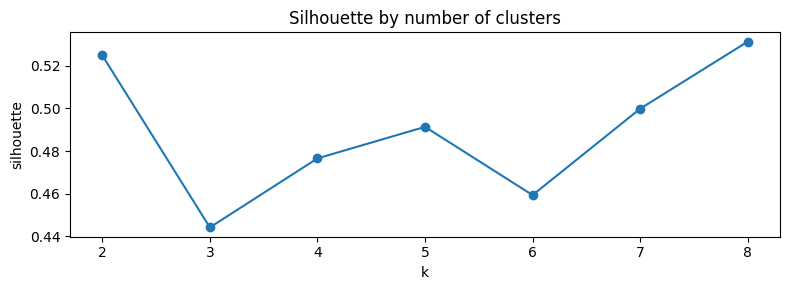

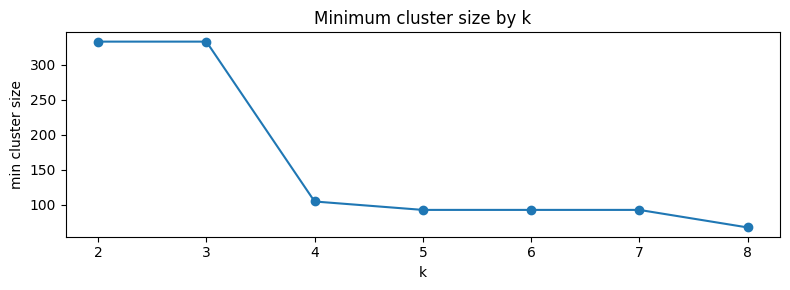

In [35]:
plt.figure(figsize=(8, 3))
plt.plot(diag["k"], diag["silhouette"], marker="o")
plt.title("Silhouette by number of clusters")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(diag["k"], diag["min_cluster_size"], marker="o")
plt.title("Minimum cluster size by k")
plt.xlabel("k")
plt.ylabel("min cluster size")
plt.tight_layout()
plt.show()

I select a baseline k based on a balance of silhouette and interpretability. I then fit the hierarchical clustering model and assign each county a trajectory type label.

In [36]:
K = int(diag.sort_values(["silhouette", "min_cluster_size"], ascending=False).iloc[0]["k"])
K

8

k=8 gives highest silhouette but produces smaller clusters,
k=5 balances separation and interpretability

In [37]:
K = 5
hclust = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels = hclust.fit_predict(X_scaled)

out = X.copy()
out["traj_cluster"] = labels

out = out.merge(
  feat.reset_index()[["county_fips_code", "county_name", "state_name", "state_abbreviation"]],
  left_index=True,
  right_on="county_fips_code",
  how="left"
).set_index("county_fips_code")

out.head()

,slope,volatility,max_abs_change,traj_cluster,county_name,state_name,state_abbreviation
county_fips_code,,,,,,,
01001,0.260380,0.953463,0.663447,0,Autauga County,Alabama,AL
01003,0.197133,0.953463,0.801740,0,Baldwin County,Alabama,AL
01005,0.233291,0.953463,0.522437,0,Barbour County,Alabama,AL
01007,0.291265,0.953463,0.409049,0,Bibb County,Alabama,AL
01009,0.275001,0.953463,0.602262,0,Blount County,Alabama,AL


In [38]:
cluster_sizes = out["traj_cluster"].value_counts().sort_index()
cluster_profile = out.groupby("traj_cluster")[use_cols].mean()

display(cluster_sizes.to_frame("n_counties"))
cluster_profile

,n_counties
traj_cluster,
0,1085
1,93
2,569
3,105
4,135


,slope,volatility,max_abs_change
traj_cluster,,,
0,0.272453,0.953463,0.829331
1,0.118673,0.953245,2.541922
2,0.306211,0.947942,0.937364
3,0.028643,0.942809,1.204446
4,-0.010041,0.952153,1.320013


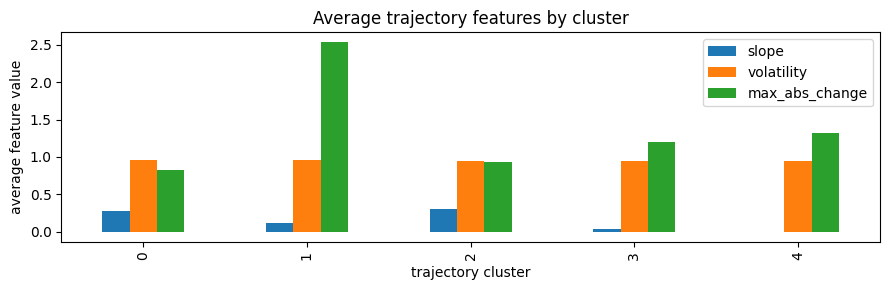

In [39]:
cluster_profile.plot(kind="bar", figsize=(9, 3))
plt.title("Average trajectory features by cluster")
plt.xlabel("trajectory cluster")
plt.ylabel("average feature value")
plt.tight_layout()
plt.show()

The diagnostics suggest gradual rather than sharply separated structure. Although higher k values slightly increase silhouette, they also create smaller and less interpretable clusters. I therefore select k equals 5 as a balanced solution.

The five trajectory types differ meaningfully in long term trend and spike behavior. Some clusters show steady upward growth, some remain relatively flat. These patterns indicate that counties follow a limited number of recurring growth shapes.

## 4.Robustness and sensitivity checks

In this section I test whether the identified trajectory types are stable under reasonable changes in assumptions. First I vary the coverage threshold because missing years can distort trajectories. Second I vary simple preprocessing choices such as interpolation and a light outlier cap. Third I use bootstrap resampling across counties to see whether the same cluster profiles reappear.

Baseline Setup

In [40]:
min_years = MIN_YEARS_REQUIRED
max_gap = MAX_INTERP_GAP

df = child.loc[child["study_year"].between(START_YEAR, END_YEAR), ["county_fips_code", "study_year", "mc_infant"]]
panel = df.pivot_table(index="county_fips_code", columns="study_year", values="mc_infant", aggfunc="median")
panel = panel.interpolate(axis=1, limit=max_gap, limit_area="inside")
panel = panel.loc[panel.notna().sum(axis=1) >= min_years]

Z = panel.sub(panel.mean(axis=1), axis=0).div(panel.std(axis=1).replace(0, np.nan), axis=0)
years = Z.columns.values.astype(float)

def make_features(row):
  y = row.values
  m = ~np.isnan(y)
  if m.sum() < 3:
    return pd.Series({"slope": np.nan, "volatility": np.nan, "max_abs_change": np.nan})
  x = years[m]
  yv = y[m]
  return pd.Series({"slope": np.polyfit(x, yv, 1)[0], "volatility": np.std(yv), "max_abs_change": np.max(np.abs(np.diff(yv))) if len(yv) > 1 else 0})

feat_base = Z.apply(make_features, axis=1).dropna()

Xs = StandardScaler().fit_transform(feat_base)
labels_base = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(Xs)

feat_base["traj_cluster"] = labels_base
feat_base.groupby("traj_cluster").mean()

,slope,volatility,max_abs_change
traj_cluster,,,
0,0.272453,0.953463,0.829331
1,0.118673,0.953245,2.541922
2,0.306211,0.947942,0.937364
3,0.028643,0.942809,1.204446
4,-0.010041,0.952153,1.320013


### 1)Coverage threshold sensitivity

In [41]:
coverage_grid = [7, 8, 9]
coverage_results = []
coverage_profiles = {}

for min_years in coverage_grid:
  panel_tmp = df.pivot_table(index="county_fips_code", columns="study_year", values="mc_infant", aggfunc="median")
  panel_tmp = panel_tmp.interpolate(axis=1, limit=MAX_INTERP_GAP, limit_area="inside")
  panel_tmp = panel_tmp.loc[panel_tmp.notna().sum(axis=1) >= min_years]

  Z_tmp = panel_tmp.sub(panel_tmp.mean(axis=1), axis=0).div(panel_tmp.std(axis=1).replace(0, np.nan), axis=0)
  feat_tmp = Z_tmp.apply(make_features, axis=1).dropna()
  X_tmp = StandardScaler().fit_transform(feat_tmp)
  labels_tmp = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(X_tmp)

  feat_tmp["traj_cluster"] = labels_tmp
  profile_tmp = feat_tmp.groupby("traj_cluster")[["slope", "volatility", "max_abs_change"]].mean()

  coverage_profiles[min_years] = profile_tmp
  coverage_results.append({"min_years": min_years, "n_counties": feat_tmp.shape[0], "min_cluster_size": feat_tmp["traj_cluster"].value_counts().min()})

pd.DataFrame(coverage_results)

,min_years,n_counties,min_cluster_size
0,7,2050,50
1,8,1987,93
2,9,1984,91


I vary the minimum number of observed years and rerun the same pipeline.

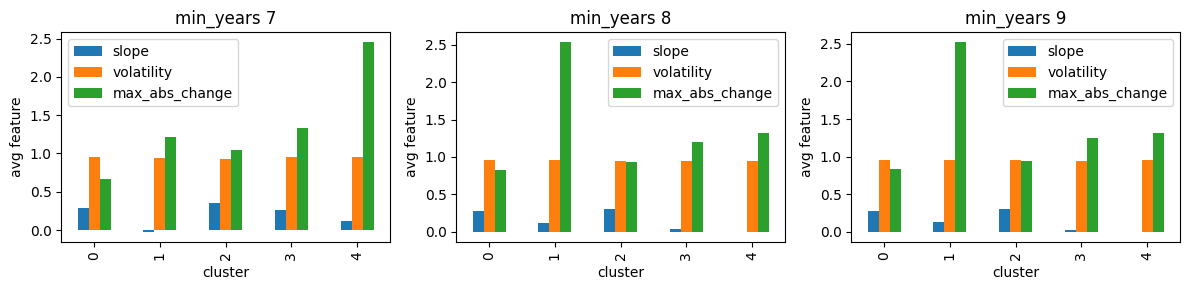

In [42]:
fig, axes = plt.subplots(1, len(coverage_grid), figsize=(4*len(coverage_grid), 3))
if len(coverage_grid) == 1:
    axes = [axes]

for ax, min_years in zip(axes, coverage_grid):
  coverage_profiles[min_years].plot(kind="bar", ax=ax)
  ax.set_title(f"min_years {min_years}")
  ax.set_xlabel("cluster")
  ax.set_ylabel("avg feature")
  ax.legend(loc="best")

plt.tight_layout()
plt.show()

Across coverage thresholds from 7 to 9 years, the overall cluster profiles remain highly similar. The relative ordering of clusters by slope volatility and maximum annual change does not materially shift, suggesting that the identified trajectory types are not driven by marginal counties with sparse reporting.

### 2)Preprocessing sensitivity

I test whether small preprocessing choices change the main story. I compare the baseline setting to a stricter no interpolation setting and to a light outlier cap in the standardized series. The goal is to check whether the same trajectory types still appear under reasonable alternatives.

In [43]:
prep_settings = [("baseline", 1, None), ("no_interp", 0, None), ("cap_z_3", 1, 3)]
prep_results = []
prep_profiles = {}

for name, gap, cap in prep_settings:
  panel_tmp = df.pivot_table(index="county_fips_code", columns="study_year", values="mc_infant", aggfunc="median")
  if gap > 0:
      panel_tmp = panel_tmp.interpolate(axis=1, limit=gap, limit_area="inside")
  panel_tmp = panel_tmp.loc[panel_tmp.notna().sum(axis=1) >= MIN_YEARS_REQUIRED]

  Z_tmp = panel_tmp.sub(panel_tmp.mean(axis=1), axis=0).div(panel_tmp.std(axis=1).replace(0, np.nan), axis=0)
  if cap is not None:
    Z_tmp = Z_tmp.clip(-cap, cap)

  feat_tmp = Z_tmp.apply(make_features, axis=1).dropna()

  X_tmp = StandardScaler().fit_transform(feat_tmp)
  labels_tmp = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(X_tmp)

  feat_tmp["traj_cluster"] = labels_tmp
  profile_tmp = feat_tmp.groupby("traj_cluster")[["slope", "volatility", "max_abs_change"]].mean()

  prep_profiles[name] = profile_tmp
  prep_results.append({"variant": name, "n_counties": feat_tmp.shape[0], "min_cluster_size": int(feat_tmp["traj_cluster"].value_counts().min())})

pd.DataFrame(prep_results)

,variant,n_counties,min_cluster_size
0,baseline,1987,93
1,no_interp,1987,93
2,cap_z_3,1987,93


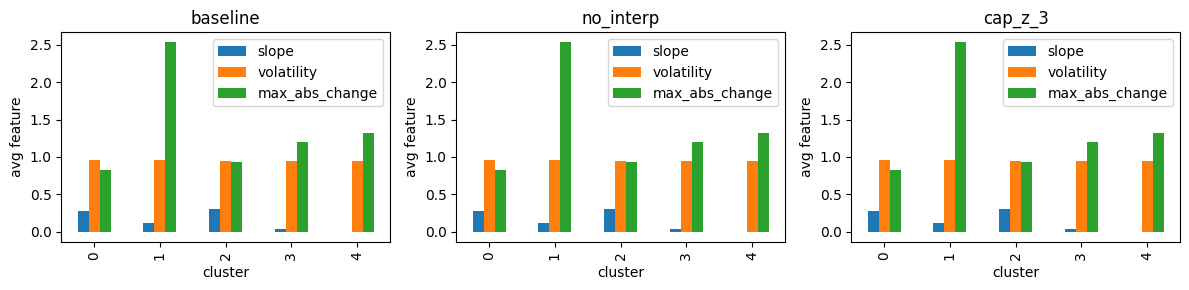

In [44]:
fig, axes = plt.subplots(1, len(prep_settings), figsize=(4*len(prep_settings), 3))
if len(prep_settings) == 1:
    axes = [axes]

for ax, (name, _, _) in zip(axes, prep_settings):
    prep_profiles[name].plot(kind="bar", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("cluster")
    ax.set_ylabel("avg feature")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

Preprocessing variants also lead to very similar feature profiles. The no interpolation setting reduces the sample slightly, and the light outlier cap slightly compresses extreme values, but the qualitative structure of the five trajectory types remains intact. This indicates that the main conclusions are not artifacts of interpolation or extreme spikes.

### 3)Bootstrap stability

I resample counties and check whether cluster size patterns remain stable.

In [45]:
boot_stats = []
ids = feat_base.index.values

for b in range(15):
  samp = np.random.choice(ids, size=int(0.8 * len(ids)), replace=True)
  samp = np.unique(samp)

  feat_tmp = feat_base.loc[samp, ["slope", "volatility", "max_abs_change"]]
  X_tmp = StandardScaler().fit_transform(feat_tmp)
  labels_tmp = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(X_tmp)
  sizes = pd.Series(labels_tmp).value_counts()
  boot_stats.append({"boot": b, "n_counties": len(samp), "min_cluster_size": sizes.min(), "max_cluster_size": sizes.max()})

pd.DataFrame(boot_stats).describe()

,boot,n_counties,min_cluster_size,max_cluster_size
count,15.000000,15.000000,15.000000,15.000000
mean,7.000000,1092.866667,52.266667,512.333333
std,4.472136,11.550304,9.414781,71.454948
min,0.000000,1072.000000,36.000000,315.000000
25%,3.500000,1085.500000,45.500000,490.500000
50%,7.000000,1092.000000,51.000000,498.000000
75%,10.500000,1102.500000,59.500000,566.000000
max,14.000000,1107.000000,69.000000,613.000000


Bootstrap resampling further supports stability. Cluster sizes remain within a comparable range across resamples, and no resample produces extreme fragmentation. Taken together, these checks suggest that the identified trajectory types reflect a stable underlying structure rather than a fragile modeling choice.

## 5.Method Upgrade

I apply K means as a sanity check to the same small set of interpretable trajectory features used for hierarchical clustering. The goal is to see whether the overall structure is consistent across algorithms.

I compare the two labelings using adjusted rand index which measures agreement up to label permutation. High agreement would suggest that the identified structure is not driven by a single clustering algorithm. Lower agreement would suggest that boundaries are gradual and algorithm dependent.

In [46]:
X = feat_base[["slope", "volatility", "max_abs_change"]].copy()
Xs = StandardScaler().fit_transform(X)
labels_h = feat_base["traj_cluster"].values

In [47]:
kmeans = KMeans(n_clusters=K, n_init=20, random_state=42)
labels_k = kmeans.fit_predict(Xs)

ari = adjusted_rand_score(labels_h, labels_k)
print("Adjusted Rand Index between hierarchical and K means", round(float(ari), 3))

Adjusted Rand Index between hierarchical and K means 0.696


In [48]:
profile_h = X.assign(cluster=labels_h).groupby("cluster").mean()
profile_k = X.assign(cluster=labels_k).groupby("cluster").mean()

display(profile_h.round(3))
display(profile_k.round(3))

,slope,volatility,max_abs_change
cluster,,,
0,0.272,0.953,0.829
1,0.119,0.953,2.542
2,0.306,0.948,0.937
3,0.029,0.943,1.204
4,-0.010,0.952,1.320


,slope,volatility,max_abs_change
cluster,,,
0,0.310,0.948,0.825
1,0.247,0.952,1.567
2,0.010,0.953,1.817
3,0.280,0.953,0.694
4,-0.006,0.944,1.201


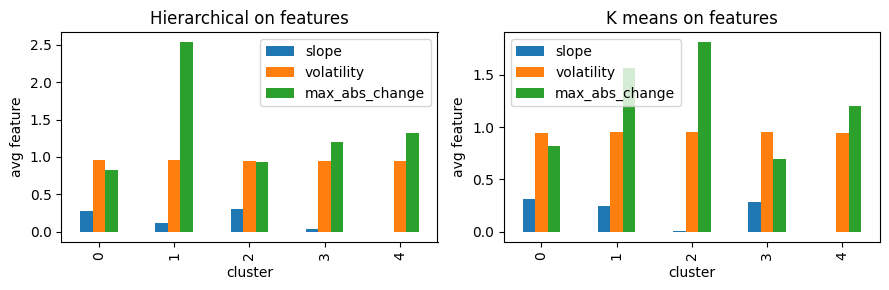

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))

profile_h.plot(kind="bar", ax=axes[0])
axes[0].set_title("Hierarchical on features")
axes[0].set_xlabel("cluster")
axes[0].set_ylabel("avg feature")
axes[0].legend(loc="best")

profile_k.plot(kind="bar", ax=axes[1])
axes[1].set_title("K means on features")
axes[1].set_xlabel("cluster")
axes[1].set_ylabel("avg feature")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

Applying K means to the same trajectory feature space yields cluster profiles that are broadly similar to those obtained from hierarchical clustering. Both methods identify a group with pronounced spike behavior in max_abs_change, groups with moderate positive slope, and groups with near flat trends. The adjusted rand index indicates partial agreement, which is consistent with gradual rather than sharply separated structure.

## 6.Integration with 2018 backbone and state structure


In this final step I reconnect the trajectory types to the broader project framework. I examine how the five trajectory clusters relate to the 2018 backbone clusters and to state level structure.

In [50]:
traj_labels = feat_base[["traj_cluster"]].reset_index()
data_2018 = child.loc[child["study_year"] == 2018, ["county_fips_code", "mc_infant"]].copy()

merged = data_2018.merge(traj_labels, on="county_fips_code", how="inner")
merged = merged.merge(counties[["county_fips_code", "state_name", "state_abbreviation"]].drop_duplicates(), on="county_fips_code", how="left")

merged.head()

,county_fips_code,mc_infant,traj_cluster,state_name,state_abbreviation
0,01001,120.41,0,Alabama,AL
1,01003,120.41,0,Alabama,AL
2,01005,86.20,0,Alabama,AL
3,01007,104.83,0,Alabama,AL
4,01009,178.08,0,Alabama,AL


The merged dataset allows me to compare current cost levels with historical growth types.

In [51]:
cost_summary = merged.groupby("traj_cluster")["mc_infant"].mean().sort_index()
cost_summary

,mc_infant
traj_cluster,
0,166.435567
1,171.966264
2,161.302721
3,70.466386
4,168.325891


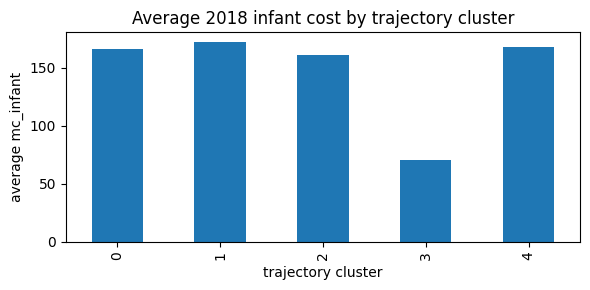

In [52]:
cost_summary.plot(kind="bar", figsize=(6,3))
plt.title("Average 2018 infant cost by trajectory cluster")
plt.xlabel("trajectory cluster")
plt.ylabel("average mc_infant")
plt.tight_layout()
plt.show()

State level trajectory distribution

In [53]:
state_dist = (merged.groupby(["state_abbreviation", "traj_cluster"]).size().unstack(fill_value=0))
state_prop = state_dist.div(state_dist.sum(axis=1), axis=0)

state_prop.head()

traj_cluster,0,1,2,3,4
state_abbreviation,,,,,
AL,1.000000,0.000000,0.0,0.0,0.000000
AZ,0.866667,0.000000,0.0,0.0,0.133333
CA,0.500000,0.086207,0.0,0.0,0.413793
CT,1.000000,0.000000,0.0,0.0,0.000000
DE,1.000000,0.000000,0.0,0.0,0.000000


Show top 6 states by number of counties

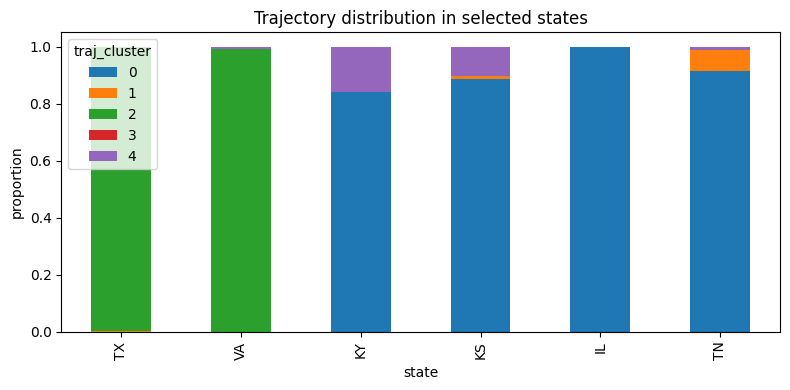

In [54]:
top_states = state_dist.sum(axis=1).sort_values(ascending=False).head(6).index

state_prop.loc[top_states].plot(kind="bar", stacked=True, figsize=(8,4))
plt.title("Trajectory distribution in selected states")
plt.xlabel("state")
plt.ylabel("proportion")
plt.tight_layout()
plt.show()

Linking trajectory types to 2018 infant cost levels shows that most clusters are associated with relatively high current costs, except one cluster. This suggests that while many counties converge to similar cost levels, they may reach them through different growth paths. In particular, the slower growth cluster appears structurally distinct in both trajectory shape and current burden.

State level distributions indicate that some states are dominated by a single trajectory type, while others show more mixed patterns. This suggests that growth dynamics are partly structured geographically, but not entirely determined by state boundaries. Overall, the integration results reinforce that childcare cost patterns reflect both persistent structural differences and diverse local growth paths.

## 7.Conclusion

In this milestone, I strengthened the credibility of the trajectory clustering results by focusing on robustness and interpretability. The five trajectory types identified earlier remain broadly stable under changes in coverage thresholds and preprocessing rules. Bootstrap resampling shows that cluster size patterns do not fragment under reasonable sampling variation, suggesting that the structure reflects consistent growth dynamics rather than random noise.

The integration analysis shows that most trajectory types converge to similar 2018 cost levels, while one cluster remains structurally lower in both growth pattern and current burden. This indicates that counties can reach similar affordability levels through different historical paths. State level distributions further suggest that some trajectory patterns are geographically concentrated, while others are more mixed, implying both structural and local influences.

Not all experiments produced sharper separation. Silhouette values did not show a single dominant peak, and method comparisons confirmed that boundaries between clusters are gradual rather than sharply defined. This reinforces the interpretation that childcare cost growth follows continuous patterns rather than perfectly distinct groups. Rather than viewing this as failure, it suggests that trajectory types should be interpreted as structural tendencies rather than rigid categories.

Overall, the results indicate that U.S. counties follow a limited number of recurring childcare cost growth shapes that are robust to reasonable modeling choices. Future work could extend this analysis to more field costs like preschool, examine policy drivers of specific trajectory types, and test whether these growth patterns predict future affordability pressures.